In [1]:
import seaborn as sns
import pandas as pd

In [2]:
df=pd.read_csv('../../Data/3. AnalysisData/df_NLP_part1.csv')

In [4]:
df

,utterance_id,conversation_id,text,speaker,movie_id,reply_to,speaker_id,character_name,movie_id.1,title,...,bechdel_score,imdb_score,numVotes,runtimeMinutes,genres,oscar,predominant_emotion,flesch_reading_ease,embedding,embedding_np
0,L1045,L1044,They do not!,u0,m0,L1044,u0,BIANCA,m0,10 things i hate about you,...,1,7.4,424659,97,"Comedy,Drama,Romance",0,neutral,119.190,[-9.06862970e-03 -1.94462873e-02 3.51809226e-...,[-9.06862970e-03 -1.94462873e-02 3.51809226e-...
1,L1044,L1044,They do to!,u2,m0,NaN,u2,CAMERON,m0,10 things i hate about you,...,1,7.4,424659,97,"Comedy,Drama,Romance",0,neutral,119.190,[ 1.61395948e-02 -2.69521493e-02 6.23717271e-...,[ 1.61395948e-02 -2.69521493e-02 6.23717271e-...
2,L985,L984,I hope so.,u0,m0,L984,u0,BIANCA,m0,10 things i hate about you,...,1,7.4,424659,97,"Comedy,Drama,Romance",0,optimism,119.190,[-1.10745057e-01 -9.88578573e-02 4.01028022e-...,[-1.10745057e-01 -9.88578573e-02 4.01028022e-...
3,L984,L984,She okay?,u2,m0,NaN,u2,CAMERON,m0,10 things i hate about you,...,1,7.4,424659,97,"Comedy,Drama,Romance",0,caring,77.905,[-3.88308689e-02 -5.65056056e-02 -1.04477738e-...,[-3.88308689e-02 -5.65056056e-02 -1.04477738e-...
4,L925,L924,Let's go.,u0,m0,L924,u0,BIANCA,m0,10 things i hate about you,...,1,7.4,424659,97,"Comedy,Drama,Romance",0,neutral,120.205,[-6.9920167e-02 -1.8361710e-02 -1.9748805e-02 ...,[-6.9920167e-02 -1.8361710e-02 -1.9748805e-02 ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137057,L665991,L665987,"I'm sorry, sir. We only seat by reservation.",u9021,m615,L665990,u9021,MAITRE D',m615,young frankenstein,...,0,8.0,176404,106,Comedy,0,remorse,65.300,[ 9.83509943e-02 -2.62434874e-02 -7.51093263e-...,[ 9.83509943e-02 -2.62434874e-02 -7.51093263e-...
137058,L665990,L665987,Food!!,u9023,m615,L665989,u9023,MONSTER,m615,young frankenstein,...,0,8.0,176404,106,Comedy,0,neutral,121.220,[-4.14033979e-02 1.52614331e-02 3.91863175e-...,[-4.14033979e-02 1.52614331e-02 3.91863175e-...
137059,L665989,L665987,Do you have a reservation?,u9021,m615,L665988,u9021,MAITRE D',m615,young frankenstein,...,0,8.0,176404,106,Comedy,0,curiosity,66.400,[ 7.48425573e-02 -2.21116878e-02 -1.04861520e-...,[ 7.48425573e-02 -2.21116878e-02 -1.04861520e-...
137060,L665988,L665987,Food!,u9023,m615,L665987,u9023,MONSTER,m615,young frankenstein,...,0,8.0,176404,106,Comedy,0,neutral,121.220,[-3.77964005e-02 2.66245250e-02 1.08059924e-...,[-3.77964005e-02 2.66245250e-02 1.08059924e-...


In [15]:
df_heatmap=df.drop(['utterance_id', 'conversation_id', 'text', 'speaker', 'movie_id', 'reply_to', 'speaker_id', 'character_name', 'movie_id.1', 'title', 'gender', 'year', 'imdbid', 'id', 'genres', 'predominant_emotion', 'embedding_np'], axis=1)

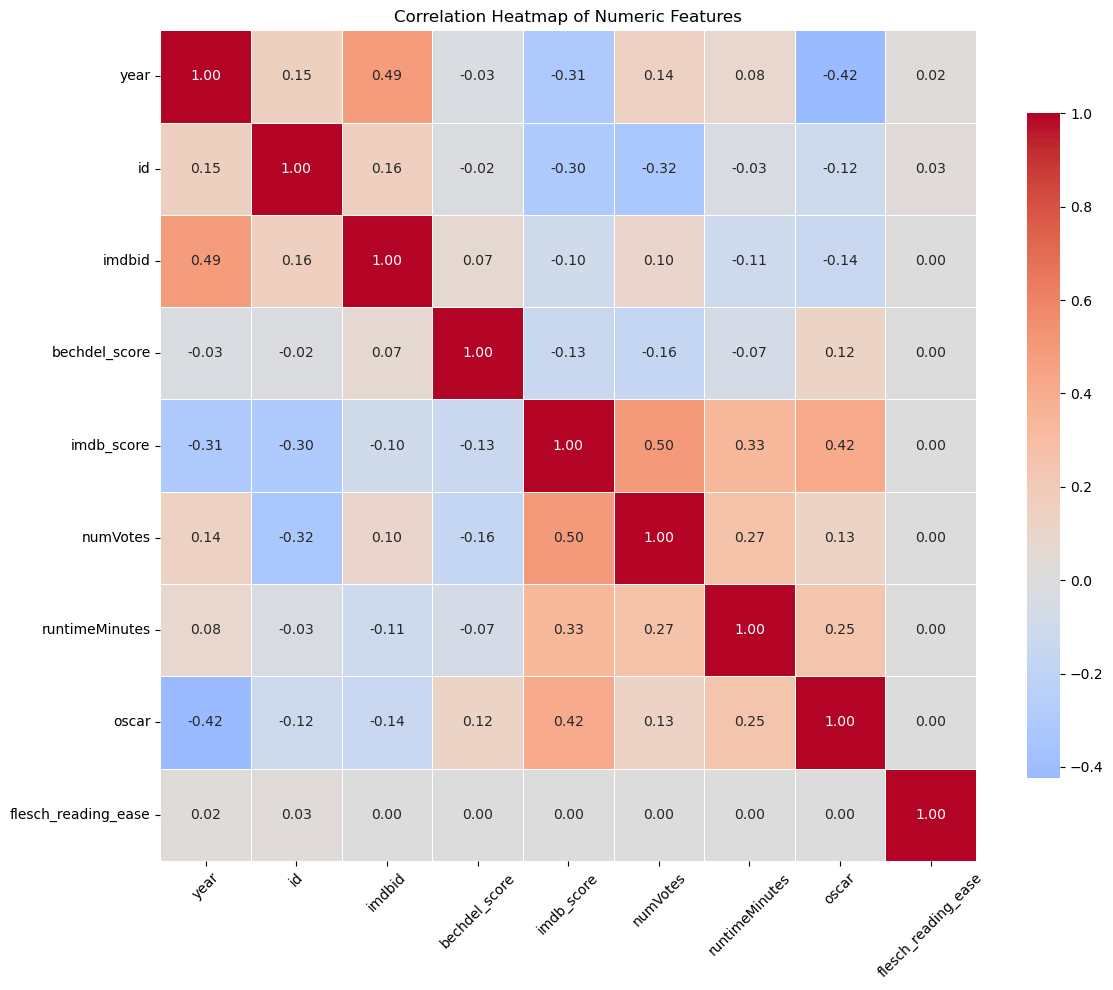

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Handle the 'embedding' column - convert to numeric features if possible
# If embedding contains lists, take the first few dimensions as features
try:
    # Try converting embeddings to numeric columns
    embedding_df = pd.DataFrame(df['embedding'].tolist()).iloc[:, :5]  # Take first 5 dimensions
    embedding_df.columns = [f'embedding_{i}' for i in range(embedding_df.shape[1])]
except Exception as e:
    print(f"Couldn't process embeddings: {e}")
    embedding_df = pd.DataFrame()

# 2. Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 3. Combine numeric columns with processed embeddings
if not embedding_df.empty:
    heatmap_df = pd.concat([df[numeric_cols], embedding_df], axis=1)
else:
    heatmap_df = df[numeric_cols]

# 4. Handle non-numeric values (like '?') by coercing to numeric
heatmap_df = heatmap_df.apply(pd.to_numeric, errors='coerce')

# 5. Drop columns that couldn't be converted
heatmap_df = heatmap_df.dropna(axis=1, how='all')

# 6. Calculate correlation matrix
corr_matrix = heatmap_df.corr()

# 7. Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm',
            center=0,
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title("Correlation Heatmap of Numeric Features")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()